# 数据增广


## 简介
基于已有数据集，增加数据集的多样性和数量，提高模型的泛化能力。
- 文本中加入同义词、近义词等
- 音频中加入噪音
- 改变图像形状、颜色等

> CES 真实案例
> 智能售货公司，在总部识别准，到会场效果很差，因为灯光、桌布等不同。他们不得不连夜训练新模型。

## 在线生成
一般使用原数据集，在训练时随机生成增广的数据样本，而不是直接存储增广数据集。
- 节省存储空间
- 增加随机性

## 常见图片增强
- **翻转**
  - 水平翻转
  - 垂直翻转（不总是可行，烟囱变井）
- **切割**
  - 随机高宽比
  - 随机大小
  - 随机位置
- **颜色**
  - 色调
  - 饱和度
  - 亮度
- **旋转**
  - 随机角度
  - 随机中心
- **视角**
  - 仿射变换
  - 透视变换
- **噪声**
  - 高斯噪声
  - 随机擦除

## 总结
- 增加噪声，起到正则化作用。
- 适应测试集或真实场景，应当基于真实场景需求实施增广
- 不是所有增广都适宜，应当根据数据集内容设计


## 实现


In [1]:
from torchvision.transforms import InterpolationMode
%matplotlib inline
import torch
from torch import nn
import torchvision
import util

/root/autodl-tmp/envs/daily_learning/lib/python3.11/site-packages/requests/__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


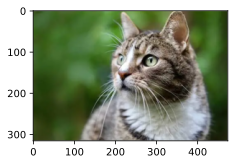

In [2]:
util.set_figsize()
img = util.Image.open('./images/cat.jpg')
util.plt.imshow(img)

辅助函数


In [3]:
def apply(img, aug, num_rows=2, num_cols=4, scale=1.5):
    """应用数据增强并显示结果"""
    Y = [aug(img) for _ in range(num_rows * num_cols)]
    util.show_images(Y, num_rows, num_cols, scale=scale)

### 翻转


水平翻转


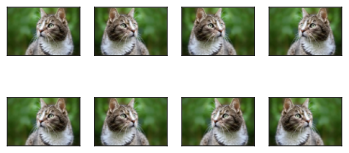

In [4]:
# RandomHorizontalFlip() 随机水平翻转图像，默认概率为 0.5
apply(img, torchvision.transforms.RandomHorizontalFlip())

垂直翻转


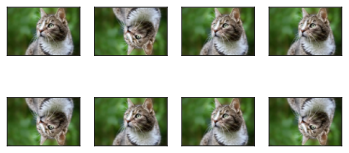

In [5]:
# RandomVerticalFlip() 随机垂直翻转图像，默认概率为 0.5
apply(img, torchvision.transforms.RandomVerticalFlip())

### 裁剪


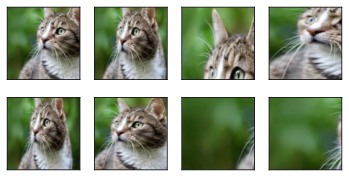

In [6]:
# RandomResizedCrop() 随机裁剪图像并缩放为指定大小
apply(img, torchvision.transforms.RandomResizedCrop(size=(200, 200), # 剪裁后重新缩放的大小
                                                    scale=(0.1, 1.0), # 裁剪区域的面积占原图面积的比例范围
                                                    ratio=(0.5, 2) # 裁剪区域的宽高比范围
                                                    ),)

### 颜色


亮度


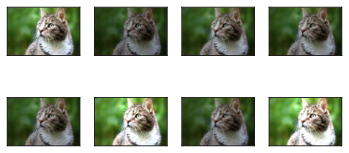

In [7]:
# ColorJitter() 随机改变图像的亮度、对比度、饱和度和色调
# brightness: 亮度 x (1-b, 1+b)
apply(img, torchvision.transforms.ColorJitter(brightness=0.5))

对比度

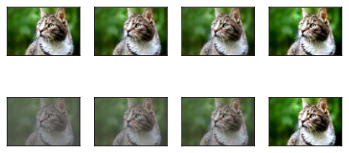

In [8]:
# contrast: 对比度 x (1-c, 1+c)
apply(img, torchvision.transforms.ColorJitter(contrast=0.7))

色调


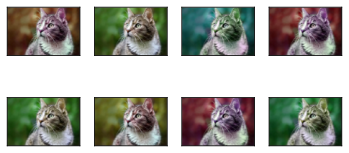

In [9]:
# hue: 色调 x (-h, h)
apply(img, torchvision.transforms.ColorJitter(hue=0.3))

饱和度

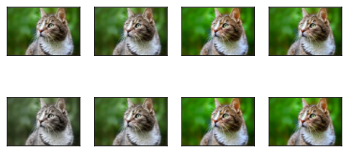

In [10]:
# saturation: 饱和度 x (1-s, 1+s)
apply(img, torchvision.transforms.ColorJitter(saturation=1))

随机更改


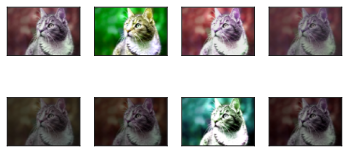

In [11]:
apply(img, torchvision.transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5, hue=0.3))

### 旋转


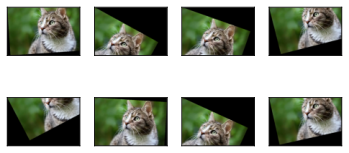

In [12]:
# degrees: 旋转角度范围 (-d, d)
# center: 旋转中心 (x, y)，默认是图像中心
apply(img, torchvision.transforms.RandomRotation(degrees=30, center=(0.5, 1)))

### 视角


仿射变换


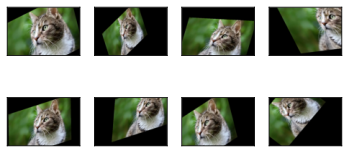

In [13]:
# degrees: 旋转角度范围 (-d, d)
# translate: 平移范围 (x, y)，表示平移的最大比例
# scale: 缩放范围 (s_min, s_max)，表示缩放的区间
# shear: 剪切角度范围 (-s, s)
apply(img, torchvision.transforms.RandomAffine(degrees=50, translate=(0.3, 0.3), scale=(0.6, 1.2), shear=30))

透视变换

interpolation 是插值法，有四种
- InterpolationMode.NEAREST: 最近邻插值
- InterpolationMode.BILINEAR: 双线性插值
- InterpolationMode.BICUBIC: 双三次插值
- InterpolationMode.NEAREST_EXACT: 最近邻插值（精确）

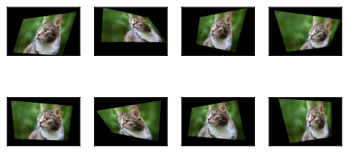

In [14]:
# distortion_scale: 透视变换的扭曲程度，范围为 [0, 1]，值越大，图像扭曲越严重
# p: 透视变换的概率，范围为 [0, 1]
apply(img, torchvision.transforms.RandomPerspective(distortion_scale=0.6, p=1,
                                                    interpolation=torchvision.transforms.functional.InterpolationMode.NEAREST))

### 噪声


高斯模糊


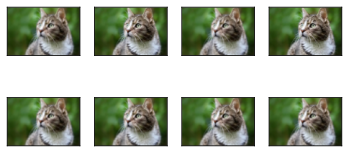

In [15]:
# kernel_size: 高斯核的大小，必须为奇数
# sigma: 高斯核的标准差，范围为 (min, max)，值越大，模糊程度越高
apply(img, torchvision.transforms.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 5)))

### 结合多种方法


结合指定方法


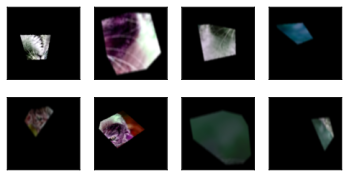

In [16]:
# Compose() 将多个数据增强方法组合在一起，按顺序依次应用
apply(img, torchvision.transforms.Compose([
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomVerticalFlip(),
    torchvision.transforms.RandomResizedCrop(size=(200, 200), scale=(0.1, 1.0), ratio=(0.5, 2)),
    torchvision.transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5, hue=0.3),
    torchvision.transforms.RandomRotation(degrees=30, center=(0.5, 1)),
    torchvision.transforms.RandomAffine(degrees=50, translate=(0.3, 0.3), scale=(0.6, 1.2), shear=30),
    torchvision.transforms.RandomPerspective(distortion_scale=0.6, p=1,
                                             interpolation=torchvision.transforms.functional.InterpolationMode.NEAREST),
    torchvision.transforms.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 5))
]))

自动增强


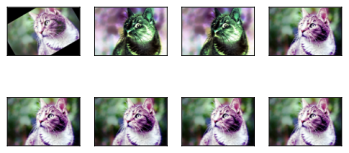

In [17]:
# AutoAugment() 自动增强方法，使用预定义的策略对图像进行增强
# policy: 预定义的增强策略，可以选择 IMAGENET、CIFAR10、SVHN 等
apply(img, torchvision.transforms.AutoAugment(policy=torchvision.transforms.AutoAugmentPolicy.IMAGENET))

随机增强


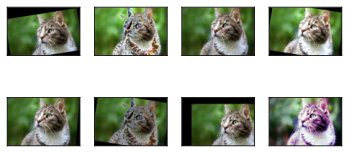

In [18]:
# num_ops: 随机选择的增强操作数量
# magnitude: 增强操作的强度，范围为 [0, 30]
apply(img, torchvision.transforms.RandAugment(num_ops=2, magnitude=9))

## 训练模型


CIFAR10 数据集


array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >], dtype=object)

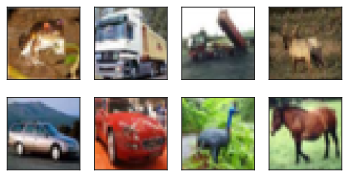

In [19]:
all_images = torchvision.datasets.CIFAR10(root="./data", train=True, download=True)
util.show_images(all_images.data[:8], 2, 4, scale=1.5)

用一下简单的增广

In [26]:
train_augs = torchvision.transforms.Compose([
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    torchvision.transforms.RandomResizedCrop(size=(32, 32), scale=(0.8, 1.0), ratio=(0.9, 1.1)),
    torchvision.transforms.ToTensor()
])
# 测试集直接 ToTensor
test_augs = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor()
])

加载到内存


In [21]:
def load_cifar10(is_train, augs, batch_size):
    dataset = torchvision.datasets.CIFAR10(root="./data", train=is_train, download=True, transform=augs)
    return torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=is_train, num_workers=10)

训练

In [22]:
def train_ch13(net, train_iter, test_iter,
               loss: torch.nn.Module,
               trainer: torch.optim.Optimizer,
               num_epochs: int,
               devices: list[torch.device]=util.try_all_gpus()):
    """训练模型，支持并行训练"""
    timer, num_batches = util.Timer(), len(train_iter)
    animator = util.Animator(xlabel='epoch', xlim=[1, num_epochs], ylim=[0, 1],
                            legend=['train loss', 'train acc', 'test acc'])
    # 使用 DataParallel 将模型复制到多个 GPU 上
    net = torch.nn.DataParallel(net, device_ids=devices).to(devices[0])
    for epoch in range(num_epochs):
        # 4个维度：储存训练损失，训练准确度，实例数，特点数
        metric = util.Accumulator(4)
        for i, (features, labels) in enumerate(train_iter):
            timer.start()
            l, acc = util.train.train_batch_ch13(
                net, features, labels, loss, trainer, devices)
            metric.add(l, acc, labels.shape[0], labels.numel())
            timer.stop()
            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches,
                             (metric[0] / metric[2], metric[1] / metric[3],
                              None))
        test_acc = util.train.evaluate_accuracy_gpu(net, test_iter)
        animator.add(epoch + 1, (None, None, test_acc))
    print(f'loss {metric[0] / metric[2]:.3f}, train acc '
          f'{metric[1] / metric[3]:.3f}, test acc {test_acc:.3f}')
    print(f'{metric[2] * num_epochs / timer.sum():.1f} examples/sec on '
          f'{str(devices)}')

In [36]:
batch_size = 256
devices = util.try_all_gpus()
lr = 0.01
num_epochs = 10

def train_with_augs(train_augs, test_augs, net, lr, num_epochs, devices):
    train_iter = load_cifar10(is_train=True, augs=train_augs, batch_size=batch_size)
    test_iter = load_cifar10(is_train=False, augs=test_augs, batch_size=batch_size)
    loss = nn.CrossEntropyLoss(reduction="none") # reduction="none" 保留每个样本的损失
    trainer = torch.optim.Adam(net.parameters(), lr=lr)
    train_ch13(net, train_iter, test_iter, loss, trainer, num_epochs, devices)

使用增广

loss 0.604, train acc 0.790, test acc 0.774
3740.7 examples/sec on [device(type='cuda', index=0), device(type='cuda', index=1), device(type='cuda', index=2), device(type='cuda', index=3)]


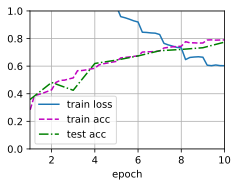

In [38]:
net = util.model.resnet18(num_classes=10, in_channels=3)
def init_weights(m):
    if type(m) in [nn.Linear, nn.Conv2d]:
        nn.init.xavier_uniform_(m.weight)
net.apply(init_weights)
train_with_augs(train_augs, test_augs, net, lr=lr, num_epochs=num_epochs, devices=devices)

不使用增广

In [ ]:
net = util.model.resnet18(num_classes=10, in_channels=3)
def init_weights(m):
    if type(m) in [nn.Linear, nn.Conv2d]:
        nn.init.xavier_uniform_(m.weight)
net.apply(init_weights)
train_with_augs(test_augs, test_augs, net, lr=lr, num_epochs=num_epochs, devices=devices)

能看出数据增广明显抑制了过拟合
